In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import logging
import seaborn as sns
import os
from typing import Union, List, Tuple, Optional
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

In [18]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Initial Data Inspection

In [19]:
df = pd.read_csv('./data/train.csv')

# Check for missing values
print(df.isnull().sum())

# Basic stats for numerical columns
display(df.describe())
df.head()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


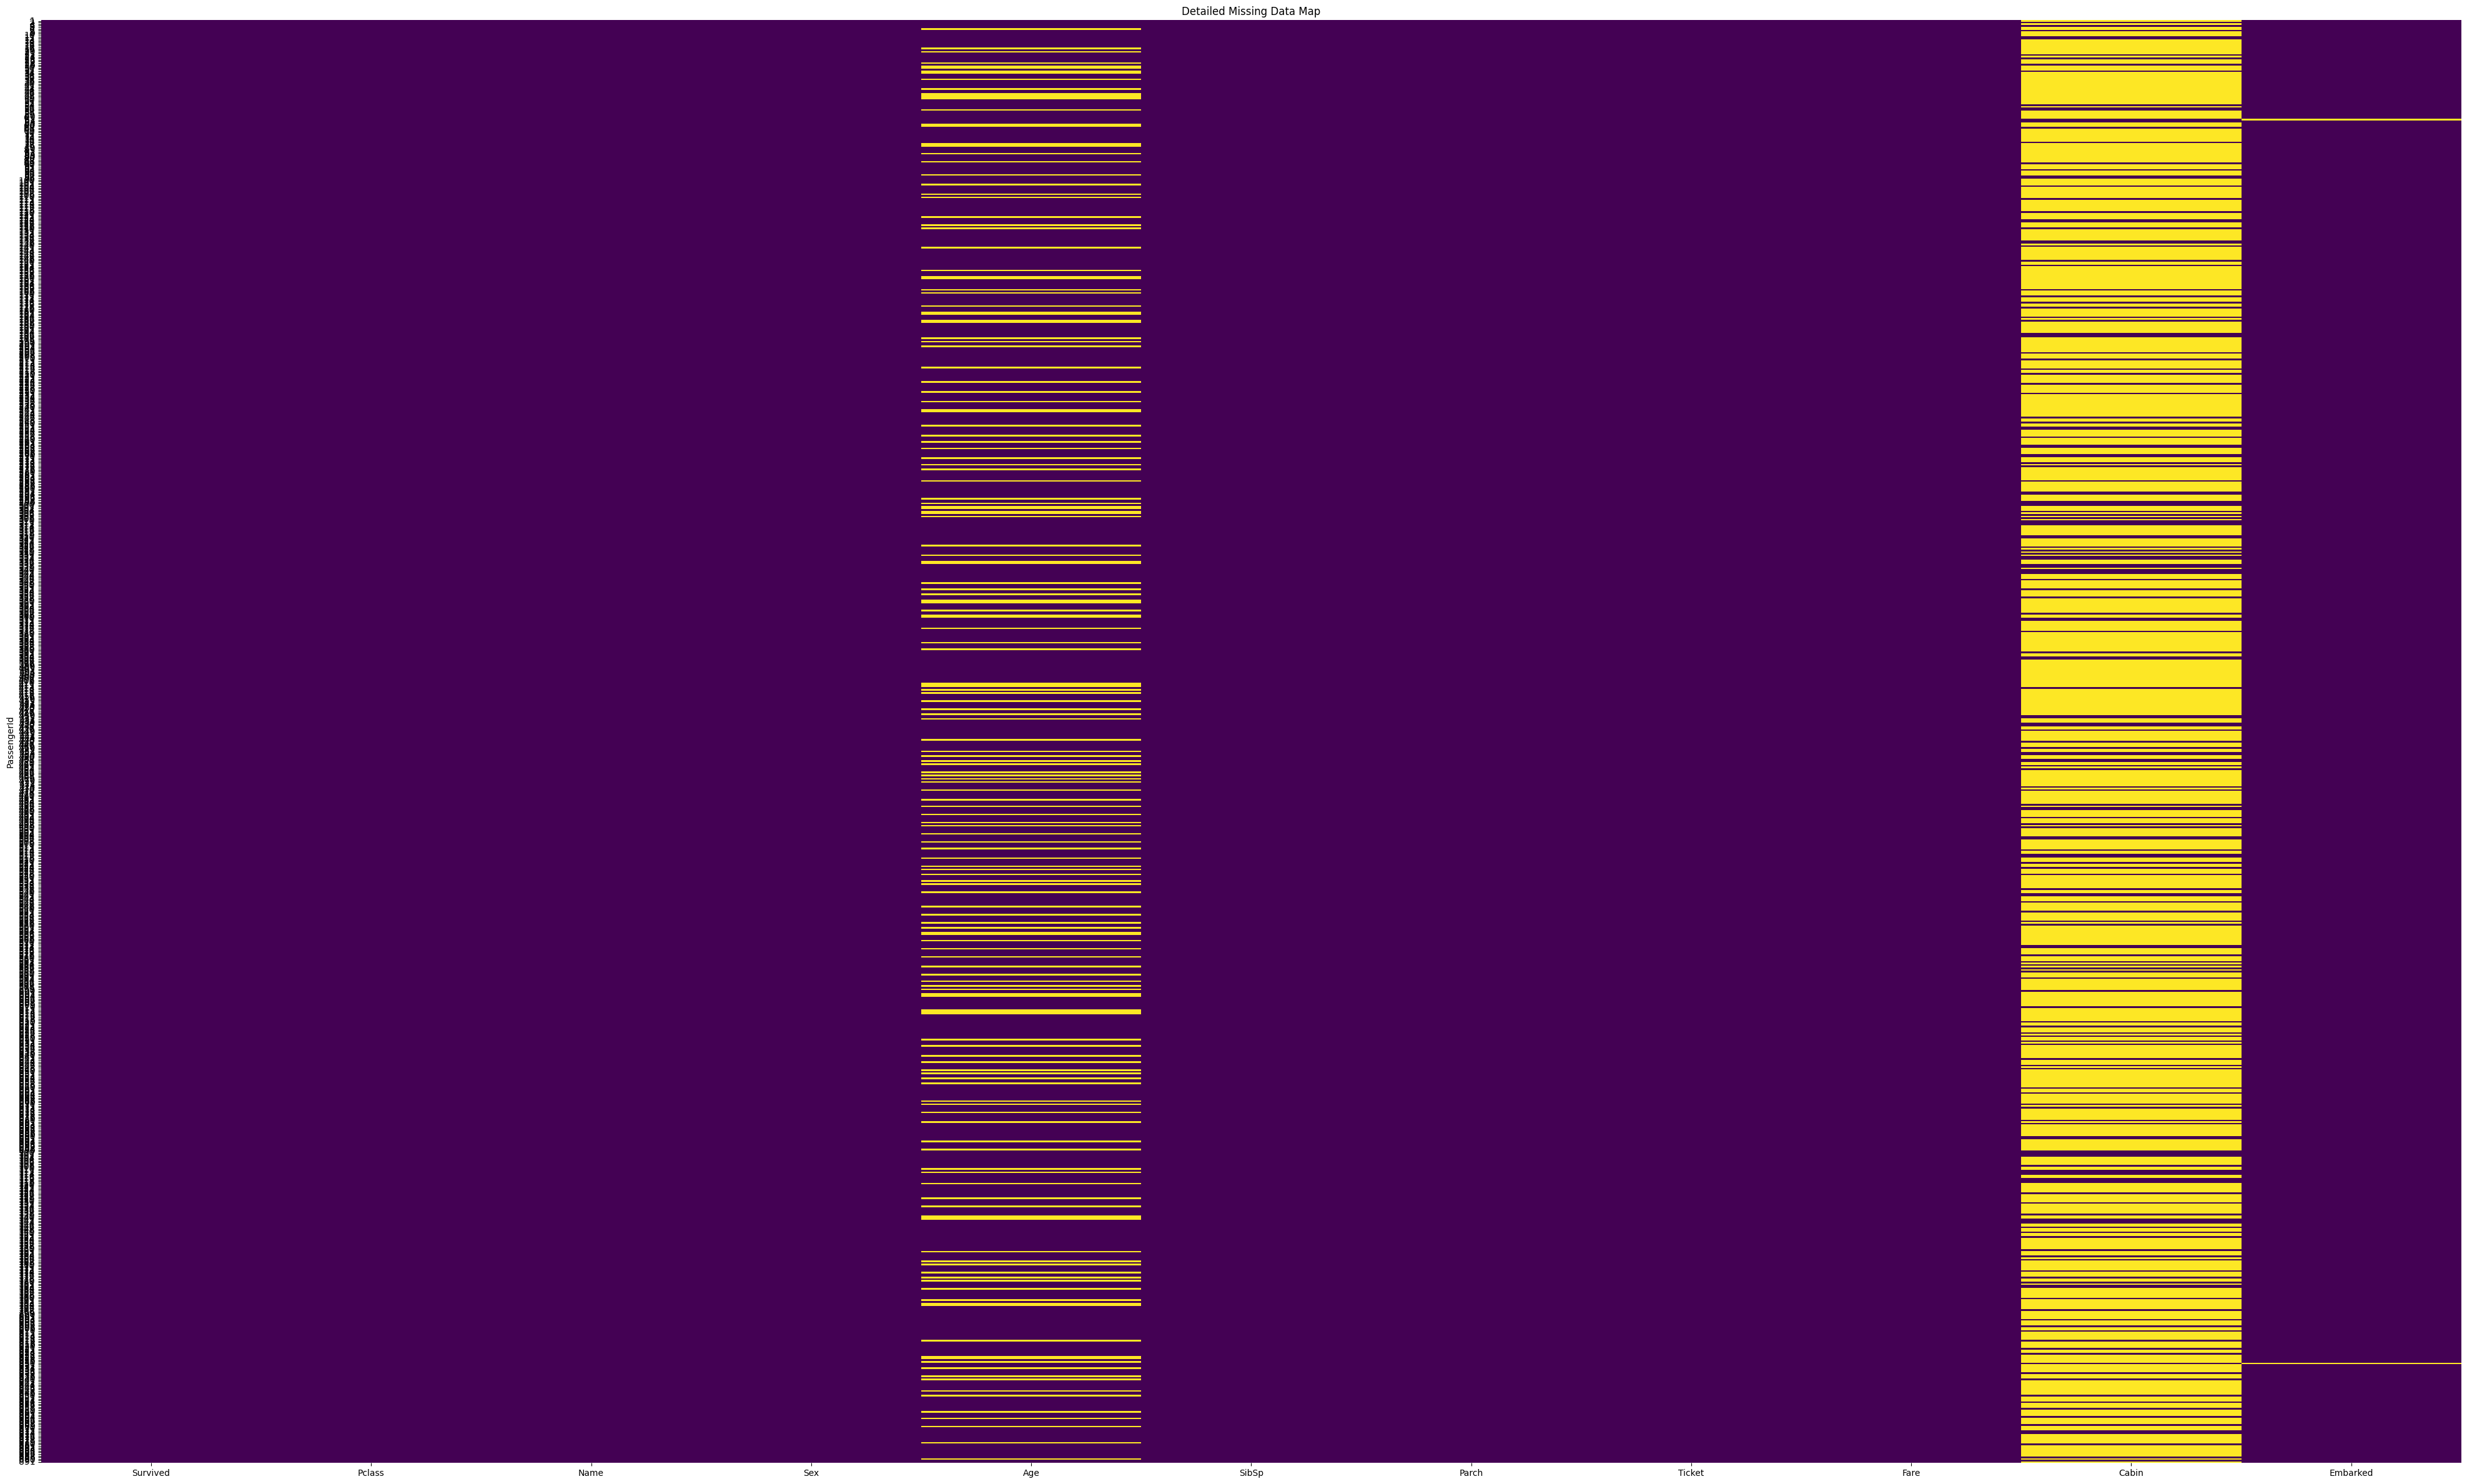

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64


In [20]:
plt.figure(figsize=(50, 30)) 

# yticklabels=1 tells seaborn to show every 1st label (every row)
sns.heatmap(df.set_index('PassengerId').isnull(), yticklabels=1, cbar=False, cmap='viridis')

plt.title('Detailed Missing Data Map')
plt.show()

missing_counts = df.isnull().sum()

# Sort them to see the "troublemakers" at the top
print(missing_counts.sort_values(ascending=False))

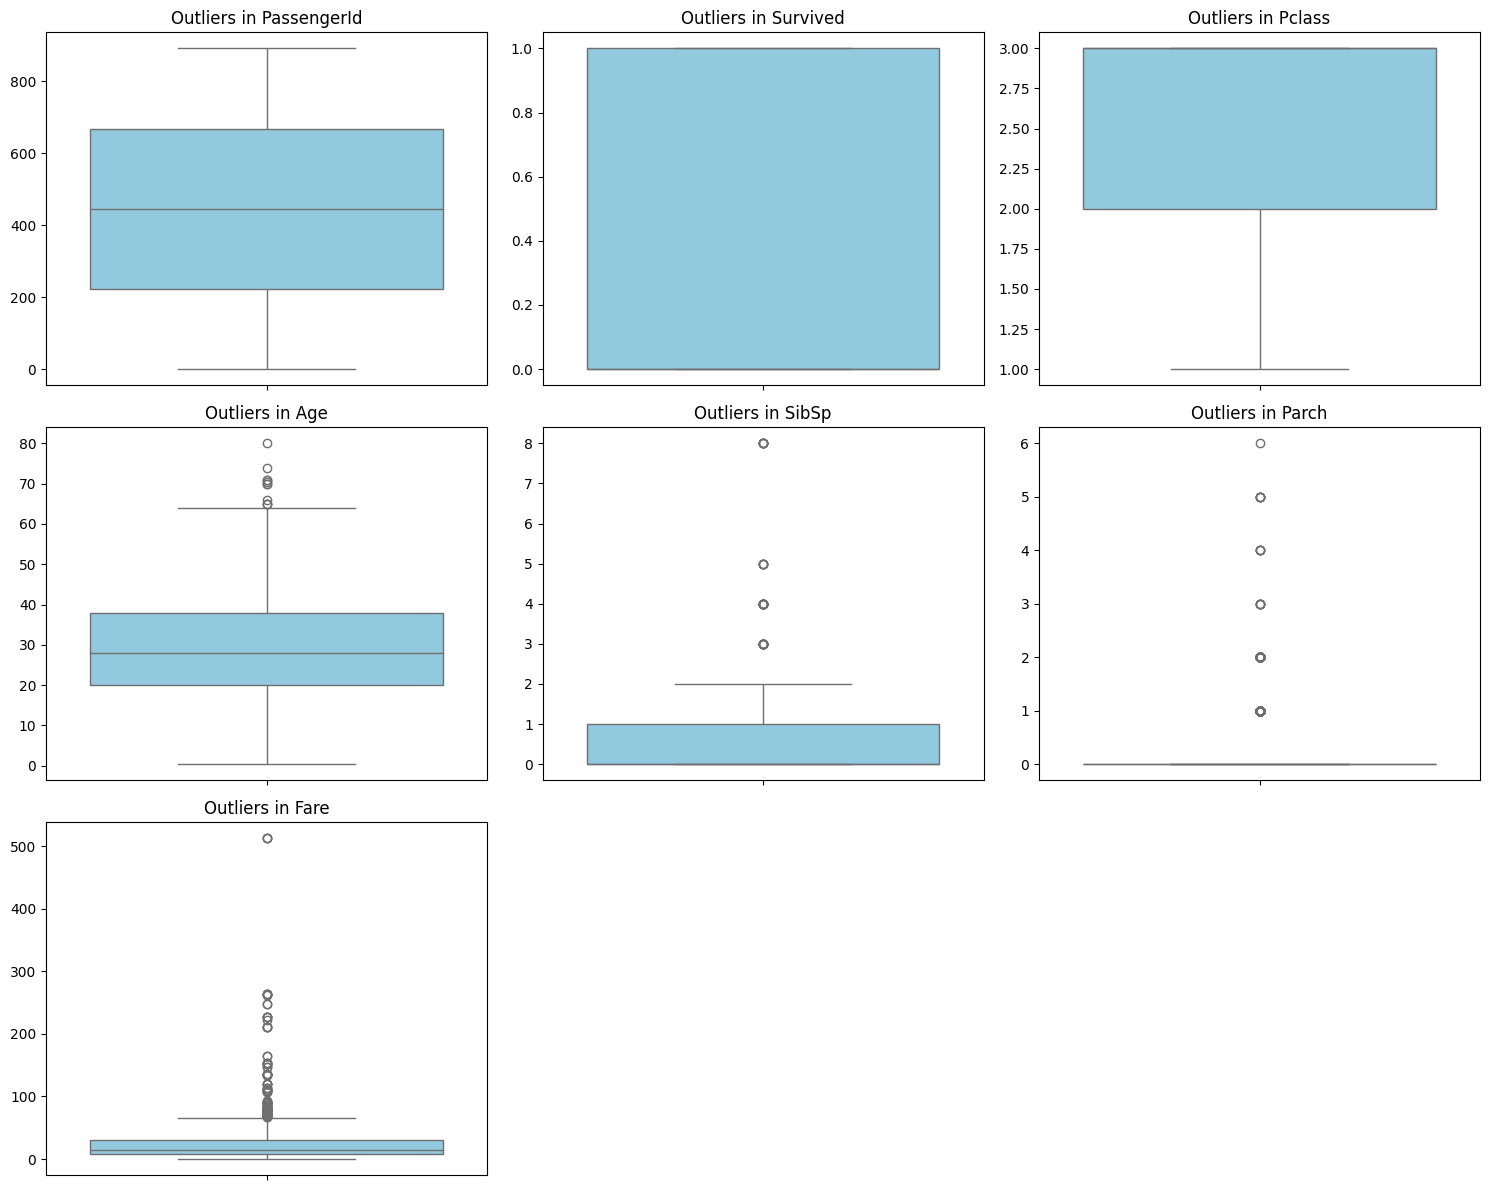

In [21]:
numeric_cols = df.select_dtypes(include=['number']).columns

# 2. Calculate the grid size (we'll do 3 plots per row)
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# 3. Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Flatten the 2D grid into a 1D list for easy looping

# 4. Loop through each numeric column and plot
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Outliers in {col}', fontsize=12)
    axes[i].set_ylabel('') # Clean up the axis labels

# 5. Hide any empty subplots (if you have, say, 7 plots in a 9-plot grid)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_68304/1684100732.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variable', y='value', data=df_melted, palette='magma')


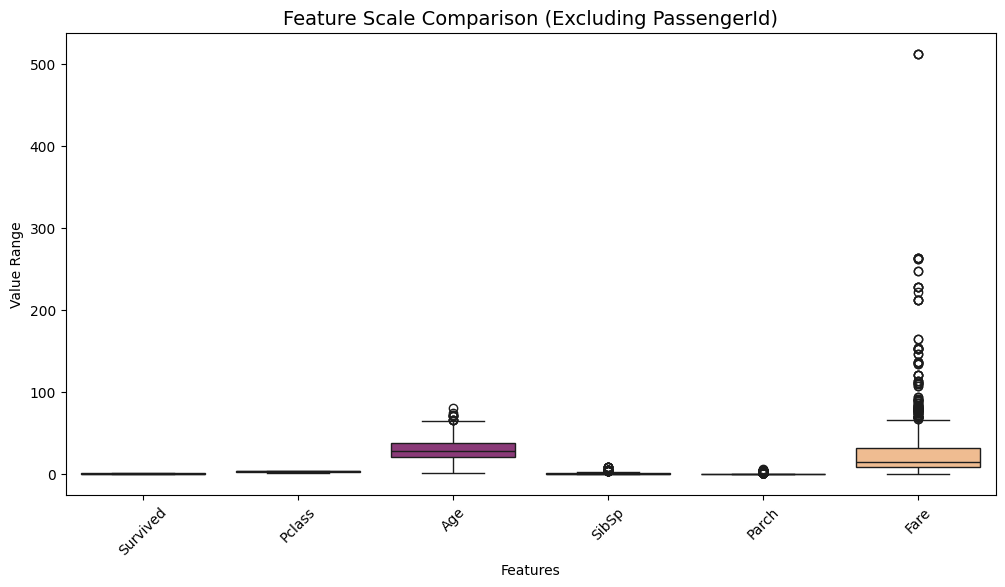

In [22]:
numeric_cols = df.select_dtypes(include=['number']).columns

# 2. Filter out 'PassengerId' if it exists in the list
# We use a list comprehension to keep everything except the ID
features_to_plot = [col for col in numeric_cols if col != 'PassengerId']

# 3. Create a temporary dataframe with only these columns and "melt" it
df_melted = df[features_to_plot].melt()

# 4. Plot the comparison
plt.figure(figsize=(12, 6))
sns.boxplot(x='variable', y='value', data=df_melted, palette='magma')

plt.title('Feature Scale Comparison (Excluding PassengerId)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Value Range')
plt.xlabel('Features')
plt.show()

2026-03-13 15:51:41,290 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_68304/3269358844.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set1')
2026-03-13 15:51:41,294 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Percentage of Survival:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


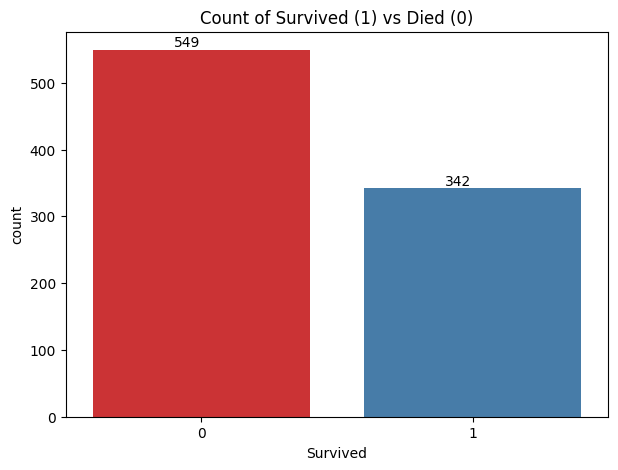

In [23]:
print("Percentage of Survival:")
print(df['Survived'].value_counts(normalize=True) * 100)
plt.figure(figsize=(7, 5))
sns.countplot(x='Survived', data=df, palette='Set1')

# Adding the exact counts on top of the bars for clarity
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 5))

plt.title('Count of Survived (1) vs Died (0)')
plt.show()

# Visualizing Key Survival Factors

A. Gender & Class (The "Big Two")

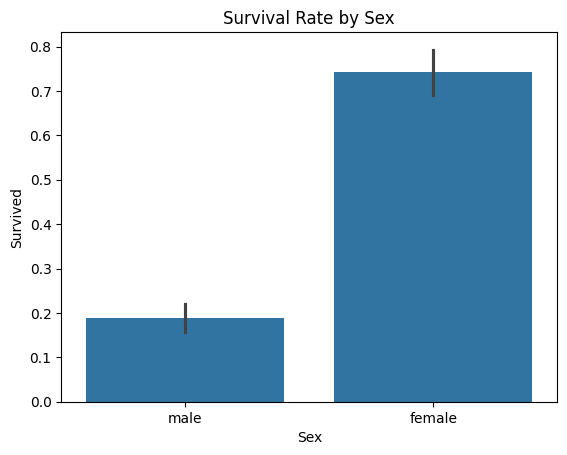

2026-03-13 15:51:41,392 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-13 15:51:41,394 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


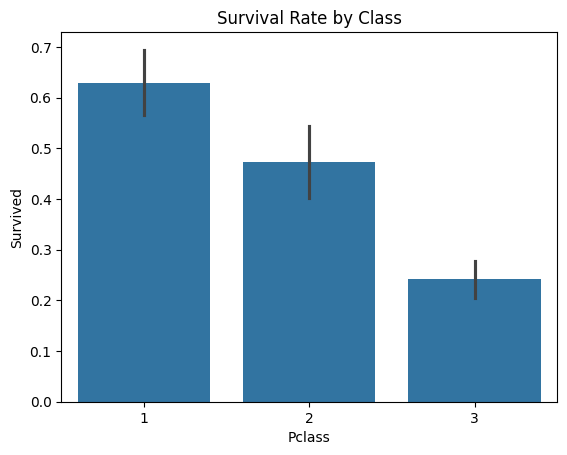

In [24]:
# Survival by Sex
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Sex')
plt.show()

# Survival by Pclass (Socio-economic status)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.show()

B. Age Distribution

Text(0.5, 1.0, 'Age Distribution of Survival')

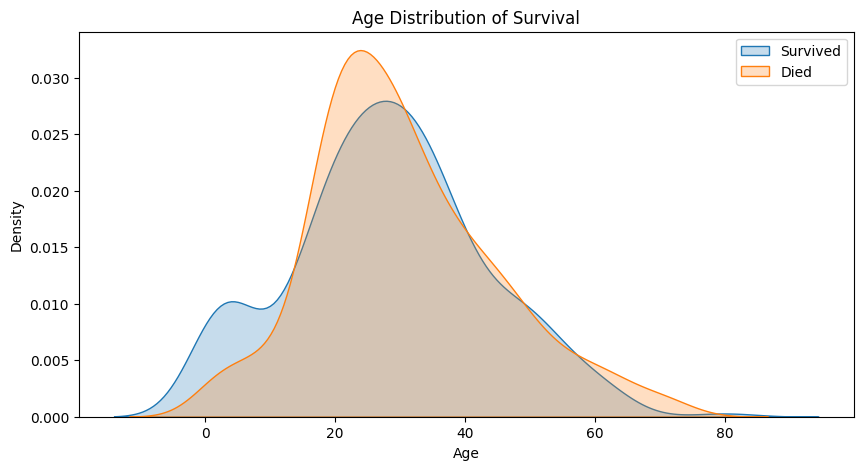

In [25]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['Survived'] == 1]['Age'].dropna(), label='Survived', fill=True)
sns.kdeplot(df[df['Survived'] == 0]['Age'].dropna(), label='Died', fill=True)
plt.legend()
plt.xlabel('Age')
plt.title('Age Distribution of Survival')

# Correlation Matrix

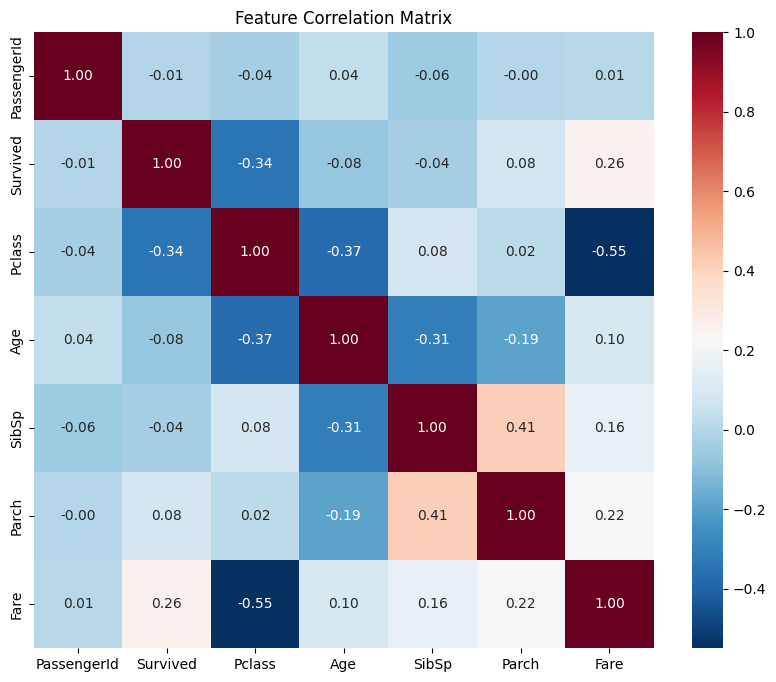

In [26]:
# Create the figure
plt.figure(figsize=(10, 8))

# Use numeric_only=True to ignore string columns like Name/Sex
corr_matrix = df.corr(numeric_only=True)

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f")

plt.title('Feature Correlation Matrix')
plt.show()

# Feature Engineering Analysis
In this section, we compare the raw data with the results of our feature engineering pipeline to see how we've addressed missing values and outliers.

In [27]:
from preprocess import *
%load_ext autoreload
%autoreload 2

# Reload raw data for comparison
df_raw = pd.read_csv('./data/train.csv')

# 1. Title Extraction Analysis
df_step = extract_titles(df_raw.copy())
print('Rare Titles found:')
print(df_step[~df_step['Title'].isin(['Mr', 'Mrs', 'Miss'])]['Title'].unique())


2026-03-13 15:51:41,623 - INFO - Extracting titles from Name column...


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Rare Titles found:
<StringArray>
['Master', 'Rare']
Length: 2, dtype: str


## Age Imputation: Solving the Peak Problem
We use KNN to fill missing ages, then bin them to smooth out the artificial 'peak' caused by mean-neighbor imputation.

2026-03-13 15:57:44,979 - INFO - Starting KNN Imputation for Age using 5 neighbors...
2026-03-13 15:57:44,990 - INFO - Age imputation complete.
2026-03-13 15:57:45,024 - INFO - Starting Age binning process...
2026-03-13 15:57:45,026 - INFO - Age successfully binned into 5 categories.


Null values before: 177
Null values after: 0


/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_68304/3029431851.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_step, x='AgeGroup', palette='viridis')


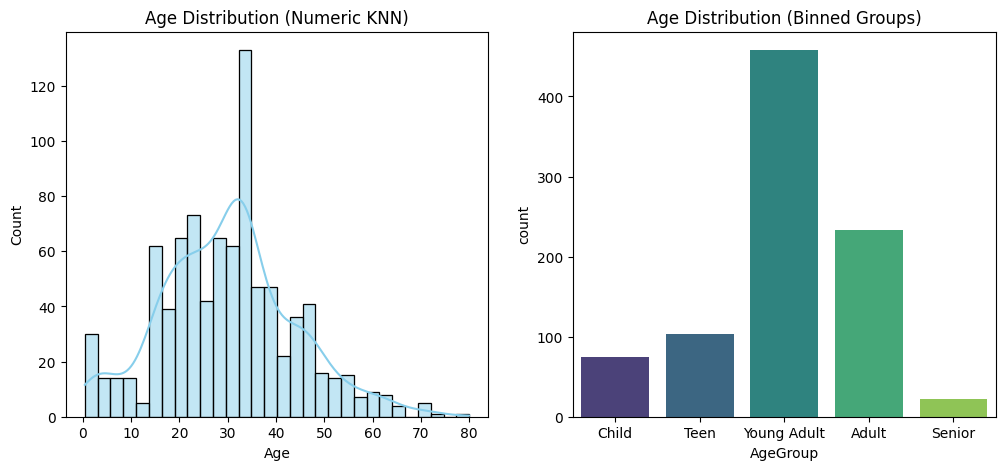

Survival Rate by Age Group:
AgeGroup
Child          0.586667
Teen           0.475728
Adult          0.416309
Young Adult    0.320961
Senior         0.227273
Name: Survived, dtype: float64


In [29]:
print(f"Null values before: {df_step['Age'].isnull().sum()}")
df_step = impute_missing_ages(df_step)
print(f"Null values after: {df_step['Age'].isnull().sum()}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_step['Age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution (Numeric KNN)')

df_step = bin_age_feature(df_step)
plt.subplot(1, 2, 2)
sns.countplot(data=df_step, x='AgeGroup', palette='viridis')
plt.title('Age Distribution (Binned Groups)')
plt.show()

print('Survival Rate by Age Group:')
print(df_step.groupby('AgeGroup')['Survived'].mean().sort_values(ascending=False))


## Cabin vs. Deck
Converting the messy Cabin column into a categorical Deck feature.

2026-03-13 15:57:59,818 - INFO - Processing Cabin column into Decks...
2026-03-13 15:57:59,821 - INFO - Deck extraction complete. Unique values: ['U', 'C', 'E', 'G', 'D', 'A', 'B', 'F']


Cabin Nulls: 687


/var/folders/wt/47l4bnlj1391yvschwmpm76c0000gq/T/ipykernel_68304/2155203306.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_step, x='Deck', palette='magma')


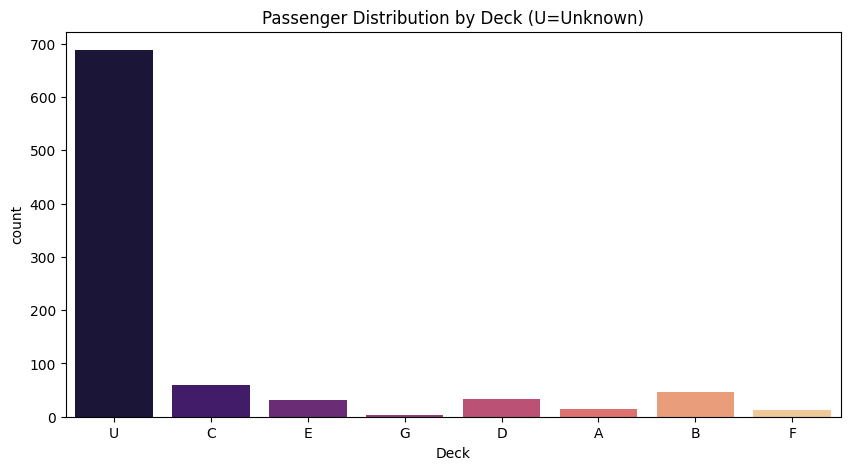

Survival Rate by Deck:
Deck
D    0.757576
E    0.750000
B    0.744681
F    0.615385
C    0.593220
G    0.500000
A    0.466667
U    0.299419
Name: Survived, dtype: float64


In [30]:
print(f"Cabin Nulls: {df_raw['Cabin'].isnull().sum()}")
df_step = process_cabin_to_deck(df_step)

plt.figure(figsize=(10, 5))
sns.countplot(data=df_step, x='Deck', palette='magma')
plt.title('Passenger Distribution by Deck (U=Unknown)')
plt.show()

print('Survival Rate by Deck:')
print(df_step.groupby('Deck')['Survived'].mean().sort_values(ascending=False))


## Fare Transformation
Using Log Transformation to handle the extreme outliers in Fare prices.

2026-03-13 15:58:17,788 - INFO - Processing Fare: applying Log1p and 4-quantile binning.
2026-03-13 15:58:17,790 - INFO - Fare features created: 'Log_Fare' and 'FareGroup'.


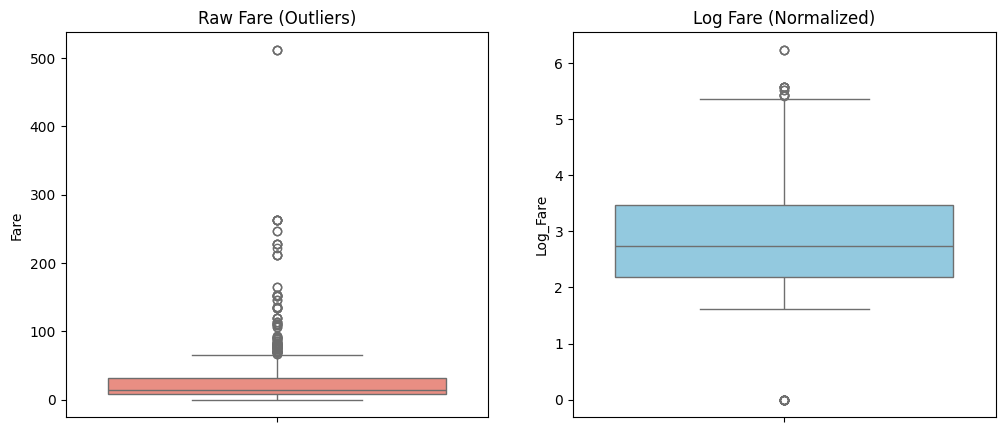

In [31]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_raw['Fare'], color='salmon')
plt.title('Raw Fare (Outliers)')

df_step = process_fare_features(df_step)
plt.subplot(1, 2, 2)
sns.boxplot(y=df_step['Log_Fare'], color='skyblue')
plt.title('Log Fare (Normalized)')
plt.show()


## Final Correlation Analysis
Comparing the survival relationship of all new features.

2026-03-13 15:58:22,726 - INFO - Creating Family-based features...
2026-03-13 15:58:22,728 - INFO - Family features created. Alone: 537, Small: 292, Large: 62
2026-03-13 15:58:22,729 - INFO - Starting categorical encoding...
2026-03-13 15:58:22,729 - INFO - Encoding Sex as binary.
2026-03-13 15:58:22,730 - INFO - One-Hot Encoding Embarked.
2026-03-13 15:58:22,735 - INFO - One-Hot Encoding Title.
2026-03-13 15:58:22,738 - INFO - One-Hot Encoding AgeGroup.
2026-03-13 15:58:22,740 - INFO - One-Hot Encoding Deck.
2026-03-13 15:58:22,742 - INFO - One-Hot Encoding FareGroup.
2026-03-13 15:58:22,744 - INFO - Encoding complete. Columns: 33
2026-03-13 15:58:22,744 - INFO - Finalizing dataframe: dropping redundant columns and setting index.
2026-03-13 15:58:22,745 - INFO - Final columns remaining: ['Survived', 'Pclass', 'Sex', 'Log_Fare', 'IsAlone', 'SmallFam', 'LargeFam', 'Port_Q', 'Port_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Age_Teen', 'Age_Young Adult', 'Age_Adult', 'Age_Se

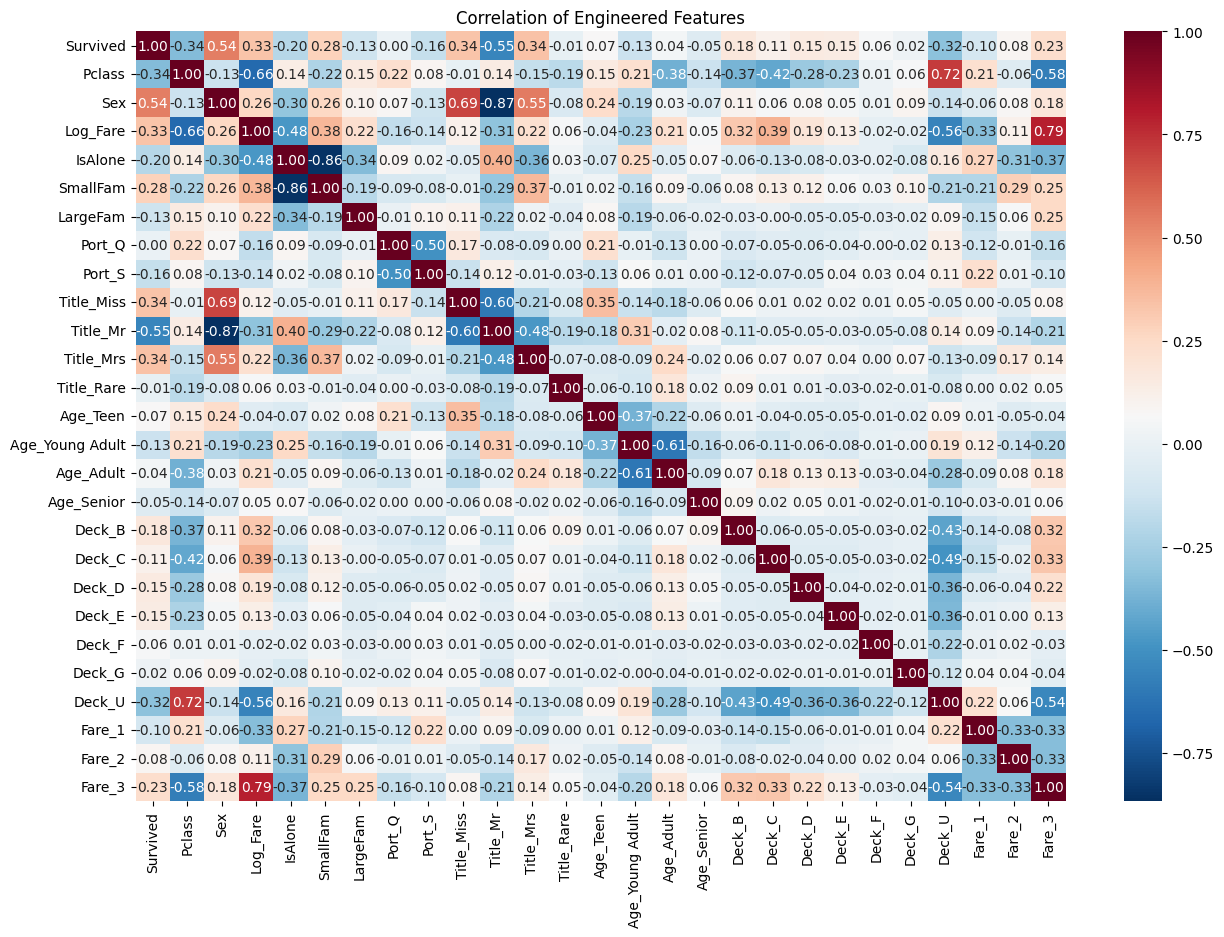

In [32]:
df_step = create_family_features(df_step)
df_final = encode_categorical_features(df_step)
df_final = finalize_features(df_final)

plt.figure(figsize=(15, 10))
sns.heatmap(df_final.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Correlation of Engineered Features')
plt.show()
